In [38]:
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

In [39]:
DATA_PATH = Path(
       "analysis_outputs/service_notices_classified_v1_1.csv"
   )

notices = pd.read_csv(
       DATA_PATH,
       dtype={
           "key": "string",
           "lg_code": "string",
           "city_code": "string",
           "project_name": "string",
           "organization_name": "string",
           "matched_subgroups": "string",
       },
   )

notices["cft_issue_date"] = pd.to_datetime(
       notices["cft_issue_date"],
       utc=True,
   ).dt.tz_convert("Asia/Tokyo")

In [41]:
print(f"Rows: {len(notices):,}")
print(f"Columns: {notices.shape[1]:,}")
print(f"IT notices: {notices['it_related'].sum():,}")
print(f"Taxonomy versions:{notices['taxonomy_version'].unique()}")

Rows: 15,230
Columns: 41
IT notices: 762
Taxonomy versions:<StringArray>
['1.1.0']
Length: 1, dtype: str


In [42]:
notices.columns.tolist()

['key',
 'project_name',
 'organization_name',
 'lg_code',
 'prefecture_name',
 'city_code',
 'city_name',
 'cft_issue_date',
 'cft_issue_year',
 'category',
 'procedure_type',
 'external_document_uri',
 'taxonomy_version',
 'it_related',
 'core_it_delivery',
 'digital_or_ai_adjacent',
 'matched_subgroups',
 'subgroup_count',
 'system_development',
 'system_services',
 'software_applications',
 'operations_maintenance',
 'cloud',
 'cybersecurity',
 'network_infrastructure',
 'end_user_computing',
 'data_digital',
 'artificial_intelligence',
 'it_consulting_planning',
 'result_id',
 'date',
 'file_type',
 'file_size',
 'certification',
 'period_end_time',
 'location',
 'tender_submission_deadline',
 'opening_tenders_event',
 'item_code',
 'attachment_count',
 'attachments_json']

In [43]:
column_summary = pd.DataFrame({
       "dtype": notices.dtypes.astype(str),
       "non_null": notices.notna().sum(),
       "missing": notices.isna().sum(),
       "unique": notices.nunique(dropna=True),
   })

column_summary

,dtype,non_null,missing,unique
key,string,15230,0,15230
project_name,string,15230,0,12690
organization_name,string,15230,0,308
lg_code,string,15230,0,6
prefecture_name,str,15230,0,6
city_code,string,11569,3661,98
city_name,str,11569,3661,98
cft_issue_date,"datetime64[us, Asia/Tokyo]",15230,0,1035
cft_issue_year,int64,15230,0,4
category,str,15230,0,1


In [44]:
important_columns = [
       "key",
       "project_name",
       "organization_name",
       "prefecture_name",
       "city_name",
       "cft_issue_date",
       "cft_issue_year",
       "it_related",
       "core_it_delivery",
       "digital_or_ai_adjacent",
       "matched_subgroups",
   ]

notices[important_columns].head(10)

,key,project_name,organization_name,prefecture_name,city_name,cft_issue_date,cft_issue_year,it_related,core_it_delivery,digital_or_ai_adjacent,matched_subgroups
0,YWljaGkvbmNnZy8yMDIyLzIwMjIwMTA0XzAwODMxCg==,実験動物飼育管理業務委託契約,国立研究開発法人国立長寿医療研究センター,愛知県,大府市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
1,Z292MTMvY2JyX21saXRfY2h1YnVfa293YW4vMjAyMi8yMDIyMDEwNF8wMDA2NQo=,令和３年度 中部地方整備局港湾WANシステム機器賃貸借,国土交通省中部地方整備局港湾空港部,愛知県,名古屋市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
2,Z292Ny9jYnJfbWxpdC8yMDIyLzIwMjIwMTA0XzAzODI0Cg==,令和４年度 越美山系電気通信施設保守業務,国土交通省中部地方整備局,愛知県,名古屋市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
3,Z292Ny9jYnJfbWxpdC8yMDIyLzIwMjIwMTA0XzAzODIxCg==,令和４年度 中部管内河川・道路管理気象予測提供業務,国土交通省中部地方整備局,愛知県,名古屋市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
4,Z292Ny9jYnJfbWxpdC8yMDIyLzIwMjIwMTA0XzAzODIyCg==,令和４年度 丸山ダム電気通信施設保守業務,国土交通省中部地方整備局,愛知県,名古屋市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
5,Z292Ny9jYnJfbWxpdC8yMDIyLzIwMjIwMTA0XzAzODIzCg==,令和４年度 横山ダム電気通信施設保守業務,国土交通省中部地方整備局,愛知県,名古屋市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
6,a2FuYWdhd2Eva2Vuc2F0c3VfeW9rb2hhbWEvMjAyMi8yMDIyMDEwNF8wMDA3Mgo=,「令和４年度保土ヶ谷区検察庁歳入金等警備輸送業務委託契約」に係る入札について,検察庁横浜地方検察庁,神奈川県,横浜市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
7,aG9ra2FpZG8vaG9ra2FpZG9fcm91ZG91a3lva3UvMjAyMi8yMDIyMDEwNF8wMTgzMAo=,令和4年度庁舎機械警備業務委託契約（34施設）,厚生労働省北海道労働局,北海道,札幌市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
8,b3Nha2EvaGlnYXNoaW9zYWthX2NpdHkvMjAyMi8yMDIyMDEwNF8wMDM5Ngo=,(R3ポ-4)自動水質監視装置及びテレメータ更新工事に伴う測量等業務委託 (サイズ：508.72KB),大阪府東大阪市,大阪府,東大阪市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
9,Z292OS9qcG5zcG9ydC8yMDIyLzIwMjIwMTA1XzAwNjYwCg==,国立代々木競技場産業廃棄物・リサイクル処理業務委託,独立行政法人日本スポーツ振興センター,東京都,港区,2022-01-05 00:00:00+09:00,2022,False,False,False,<NA>


In [45]:
assert not (
       notices["core_it_delivery"]
       & notices["digital_or_ai_adjacent"]
).any()

In [46]:
subgroup_columns = [
       "system_development",
       "system_services",
       "software_applications",
       "operations_maintenance",
       "cloud",
       "cybersecurity",
       "network_infrastructure",
       "end_user_computing",
       "data_digital",
       "artificial_intelligence",
       "it_consulting_planning",
   ]

In [47]:
notices[subgroup_columns].sum().sort_values(ascending=False)

operations_maintenance     293
system_development         227
network_infrastructure     145
software_applications       67
data_digital                55
cloud                       50
artificial_intelligence     41
cybersecurity               32
it_consulting_planning      30
system_services             19
end_user_computing           4
dtype: int64

In [48]:
sparse_columns = [
       "procedure_type",
       "period_end_time",
       "location",
       "tender_submission_deadline",
       "opening_tenders_event",
       "item_code",
   ]

notices[sparse_columns].notna().mean().sort_values()

period_end_time              0.00
location                     0.00
item_code                    0.00
tender_submission_deadline   0.01
opening_tenders_event        0.01
procedure_type               0.21
dtype: float64

In [49]:
notices[
       ["it_related", "core_it_delivery",
 "digital_or_ai_adjacent"]
   ].value_counts()

it_related  core_it_delivery  digital_or_ai_adjacent
False       False             False                     14468
True        True              False                       691
            False             True                         71
Name: count, dtype: int64

In [50]:
it_notices = notices.loc[notices["it_related"]].copy()

print(f"IT notices: {len(it_notices):,}")

IT notices: 762


In [57]:
## 1. How did IT-indicator counts and shares change from 2022 to 2025?


annual_summary = (
       notices.groupby("cft_issue_year", as_index=False)
       .agg(
           service_notices=("key", "size"),
           it_notices=("it_related", "sum"),
           core_it_notices=("core_it_delivery", "sum"),
           adjacent_only_notices=("digital_or_ai_adjacent",
 "sum"),
       )
   )

annual_summary["it_share_percent"] = (
       annual_summary["it_notices"]
       / annual_summary["service_notices"]
       * 100
   )

annual_summary["core_it_share_percent"] = (
       annual_summary["core_it_notices"]
       / annual_summary["service_notices"]
       * 100
   )

annual_summary["adjacent_only_share_percent"] = (
       annual_summary["adjacent_only_notices"]
       / annual_summary["service_notices"]
       * 100
   )


annual_summary["it_notice_absolute_change"] = (
       annual_summary["it_notices"].diff()
   )

annual_summary["it_notice_yoy_percent"] = (
       annual_summary["it_notices"].pct_change() * 100
   )

annual_summary["it_share_pp_change"] = (
       annual_summary["it_share_percent"].diff()
   )

annual_summary.round({
       "it_share_percent": 2,
       "core_it_share_percent": 2,
       "adjacent_only_share_percent": 2,
       "it_notice_yoy_percent": 1,
       "it_share_pp_change": 2,
   })



annual_summary.round({
       "it_share_percent": 2,
       "core_it_share_percent": 2,
       "adjacent_only_share_percent": 2,
       "it_notice_yoy_percent": 1,
       "it_share_pp_change": 2,
   })

annual_summary



# Absolute change: Allows us to measure the difference of it notices issued 
# YoY percentage change: How large was the change compared with where it started? 
# Percentage-point change: Did IT become a larger or smaller part of all service notices?


,cft_issue_year,service_notices,it_notices,core_it_notices,adjacent_only_notices,it_share_percent,core_it_share_percent,adjacent_only_share_percent,it_notice_absolute_change,it_notice_yoy_percent,it_share_pp_change
0,2022,2497,117,108,9,4.69,4.33,0.36,NaN,NaN,NaN
1,2023,3836,183,162,21,4.77,4.22,0.55,66.00,56.41,0.08
2,2024,4458,201,180,21,4.51,4.04,0.47,18.00,9.84,-0.26
3,2025,4439,261,241,20,5.88,5.43,0.45,60.00,29.85,1.37


In [59]:
annual_summary = annual_summary.sort_values(
       "cft_issue_year"
   ).reset_index(drop=True)

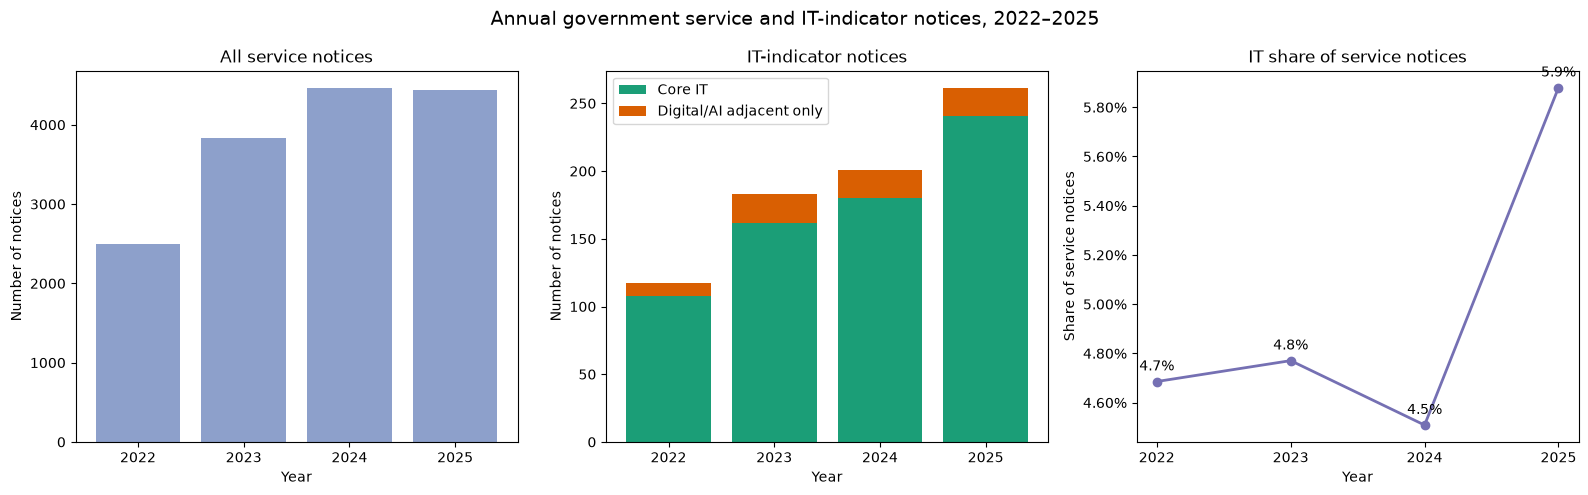

In [61]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

years = annual_summary["cft_issue_year"]

fig, axes = plt.subplots(
       1,
       3,
       figsize=(16, 5),
   )

   # Panel 1: all service notices
axes[0].bar(
       years,
       annual_summary["service_notices"],
       color="#8da0cb",
   )

axes[0].set_title("All service notices")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of notices")
axes[0].set_xticks(years)

   # Panel 2: IT notices split into core and adjacent-only
axes[1].bar(
       years,
       annual_summary["core_it_notices"],
       label="Core IT",
       color="#1b9e77",
   )

axes[1].bar(
       years,
       annual_summary["adjacent_only_notices"],
       bottom=annual_summary["core_it_notices"],
       label="Digital/AI adjacent only",
       color="#d95f02",
   )

axes[1].set_title("IT-indicator notices")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of notices")
axes[1].set_xticks(years)
axes[1].legend()

   # Panel 3: IT share of all service notices
axes[2].plot(
       years,
       annual_summary["it_share_percent"],
       marker="o",
       linewidth=2,
       color="#7570b3",
   )

axes[2].set_title("IT share of service notices")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Share of service notices")
axes[2].set_xticks(years)
axes[2].yaxis.set_major_formatter(PercentFormatter())

for year, share in zip(
       years,
       annual_summary["it_share_percent"],
       strict=True,
   ):
       axes[2].annotate(
           f"{share:.1f}%",
           (year, share),
           xytext=(0, 8),
           textcoords="offset points",
           ha="center",
       )

fig.suptitle(
       "Annual government service and IT-indicator notices, 2022–2025",
       fontsize=14,
   )

fig.tight_layout()
plt.show()

In [64]:
from pathlib import Path

Path("analysis_outputs/report_figures").mkdir(
       parents=True,
       exist_ok=True,
   )


In [66]:
fig.savefig(
       "analysis_outputs/report_figures/annual_it_trend.png",
       dpi=300,
       bbox_inches="tight",
   )

In [67]:
# 2. Which IT subgroups experienced the largest absolute and relative increases, and which gained or lost representation among IT notices

subgroup_labels = {
       "system_development": "System development",
       "system_services": "System services",
       "software_applications": "Software and applications",
       "operations_maintenance": "Operations and maintenance",
       "cloud": "Cloud",
       "cybersecurity": "Cybersecurity",
       "network_infrastructure": "Network infrastructure",
       "end_user_computing": "End-user computing",
       "data_digital": "Data and digital",
       "artificial_intelligence": "Artificial intelligence",
       "it_consulting_planning": "IT consulting and planning",
   }


In [72]:
subgroup_annual = (
       notices.groupby(
           "cft_issue_year",
           as_index=False,
       )[subgroup_columns]
       .sum()
       .melt(
           id_vars="cft_issue_year",
           var_name="subgroup",
           value_name="notice_count",
       )
   )


annual_it_totals = (
       notices.groupby(
           "cft_issue_year",
           as_index=False,
       )
       .agg(
           it_notices=("it_related", "sum"),
       )
   )

subgroup_annual = subgroup_annual.merge(
       annual_it_totals,
       on="cft_issue_year",
       validate="many_to_one",
   )

subgroup_annual["subgroup_label"] = (
       subgroup_annual["subgroup"].map(subgroup_labels)
   )


subgroup_annual = subgroup_annual.sort_values(
       ["subgroup", "cft_issue_year"]
   ).reset_index(drop=True)

subgroup_annual["previous_year_count"] = (
       subgroup_annual.groupby("subgroup")[
           "notice_count"
       ].shift(1)
   )



In [74]:
subgroup_annual["absolute_annual_change"] = (
       subgroup_annual["notice_count"]
       - subgroup_annual["previous_year_count"]
   )

In [76]:
subgroup_annual["yoy_percent"] = (
       (
           subgroup_annual["notice_count"]
           / subgroup_annual["previous_year_count"]
           - 1
       )
       * 100
   )

In [78]:
 subgroup_annual.loc[
       subgroup_annual["previous_year_count"].eq(0),
       "yoy_percent",
   ] = pd.NA

In [80]:
subgroup_annual["share_of_it_percent"] = (
       subgroup_annual["notice_count"]
       / subgroup_annual["it_notices"]
       * 100
   )

In [82]:
subgroup_annual["share_pp_change"] = (
       subgroup_annual.groupby("subgroup")[
           "share_of_it_percent"
       ].diff()
   )

In [84]:
subgroup_annual[
       [
           "cft_issue_year",
           "subgroup_label",
           "notice_count",
           "absolute_annual_change",
           "yoy_percent",
           "share_of_it_percent",
           "share_pp_change",
       ]
   ].round(2)

,cft_issue_year,subgroup_label,notice_count,absolute_annual_change,yoy_percent,share_of_it_percent,share_pp_change
0,2022,Artificial intelligence,4,NaN,NaN,3.42,NaN
1,2023,Artificial intelligence,6,2.00,50.00,3.28,-0.14
2,2024,Artificial intelligence,13,7.00,116.67,6.47,3.19
3,2025,Artificial intelligence,18,5.00,38.46,6.90,0.43
4,2022,Cloud,6,NaN,NaN,5.13,NaN
5,2023,Cloud,9,3.00,50.00,4.92,-0.21
6,2024,Cloud,14,5.00,55.56,6.97,2.05
7,2025,Cloud,21,7.00,50.00,8.05,1.08
8,2022,Cybersecurity,4,NaN,NaN,3.42,NaN
9,2023,Cybersecurity,6,2.00,50.00,3.28,-0.14


In [85]:
subgroup_wide = subgroup_annual.pivot(
       index="subgroup",
       columns="cft_issue_year",
       values=[
           "notice_count",
           "share_of_it_percent",
       ],
   )

subgroup_change_summary = pd.DataFrame({
       "count_2022": subgroup_wide["notice_count"][2022],
       "count_2025": subgroup_wide["notice_count"][2025],
       "share_2022_percent": (
           subgroup_wide["share_of_it_percent"][2022]
       ),
       "share_2025_percent": (
           subgroup_wide["share_of_it_percent"][2025]
       ),
   })


subgroup_change_summary[
       "absolute_change_2022_2025"
   ] = (
       subgroup_change_summary["count_2025"]
       - subgroup_change_summary["count_2022"]
   )





In [87]:
def calculate_cagr(
       start: float,
       end: float,
       periods: int = 3,
   ) -> float | None:
       if start <= 0:
           return None

       return ((end / start) ** (1 / periods) - 1) * 100


subgroup_change_summary[
       "cagr_2022_2025_percent"
   ] = subgroup_change_summary.apply(
       lambda row: calculate_cagr(
           row["count_2022"],
           row["count_2025"],
       ),
       axis=1,
   )

In [89]:
subgroup_change_summary[
       "share_pp_change_2022_2025"
   ] = (
       subgroup_change_summary["share_2025_percent"]
       - subgroup_change_summary["share_2022_percent"]
   )

subgroup_change_summary["subgroup_label"] = (
       subgroup_change_summary.index.map(subgroup_labels)
   )

subgroup_change_summary = (
       subgroup_change_summary
       .sort_values(
           "absolute_change_2022_2025",
           ascending=False,
       )
   )

subgroup_change_summary[
       [
           "subgroup_label",
           "count_2022",
           "count_2025",
           "absolute_change_2022_2025",
           "cagr_2022_2025_percent",
           "share_2022_percent",
           "share_2025_percent",
           "share_pp_change_2022_2025",
       ]
   ].round(2)

,subgroup_label,count_2022,count_2025,absolute_change_2022_2025,cagr_2022_2025_percent,share_2022_percent,share_2025_percent,share_pp_change_2022_2025
subgroup,,,,,,,,
system_development,System development,35.00,95.00,60.00,39.49,29.91,36.40,6.48
operations_maintenance,Operations and maintenance,43.00,87.00,44.00,26.48,36.75,33.33,-3.42
network_infrastructure,Network infrastructure,22.00,47.00,25.00,28.79,18.80,18.01,-0.80
cloud,Cloud,6.00,21.00,15.00,51.83,5.13,8.05,2.92
artificial_intelligence,Artificial intelligence,4.00,18.00,14.00,65.10,3.42,6.90,3.48
software_applications,Software and applications,9.00,22.00,13.00,34.71,7.69,8.43,0.74
cybersecurity,Cybersecurity,4.00,15.00,11.00,55.36,3.42,5.75,2.33
it_consulting_planning,IT consulting and planning,7.00,13.00,6.00,22.92,5.98,4.98,-1.00
end_user_computing,End-user computing,0.00,1.00,1.00,NaN,0.00,0.38,0.38


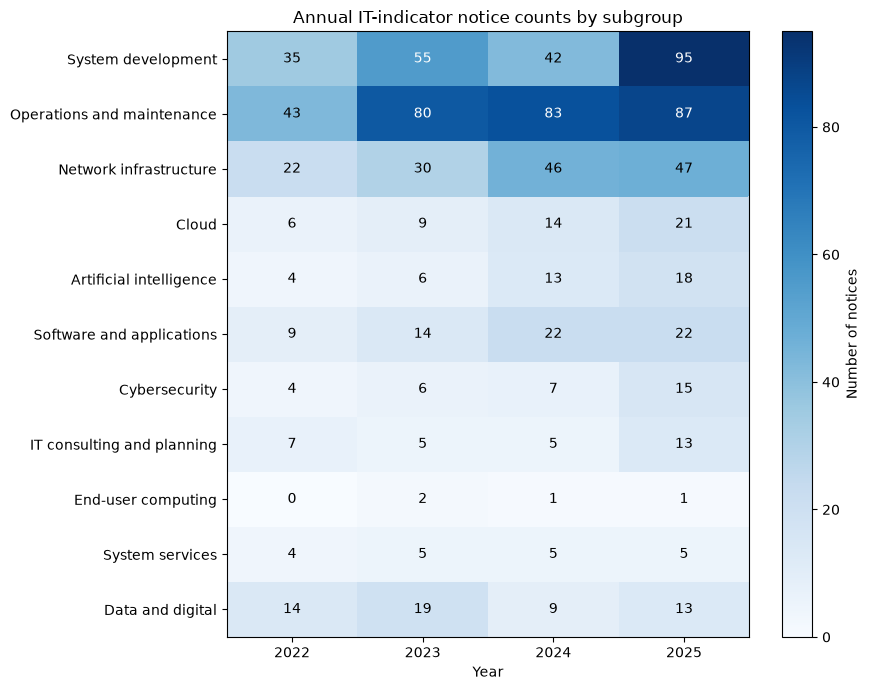

In [91]:
subgroup_matrix = (
       subgroup_annual.pivot(
           index="subgroup_label",
           columns="cft_issue_year",
           values="notice_count",
       )
       .loc[
           subgroup_change_summary["subgroup_label"]
       ]
   )

fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(
       subgroup_matrix,
       cmap="Blues",
       aspect="auto",
   )

ax.set_xticks(range(len(subgroup_matrix.columns)))
ax.set_xticklabels(subgroup_matrix.columns)

ax.set_yticks(range(len(subgroup_matrix.index)))
ax.set_yticklabels(subgroup_matrix.index)

ax.set_xlabel("Year")
ax.set_title("Annual IT-indicator notice counts by subgroup")

for row_index in range(len(subgroup_matrix.index)):
    for column_index in range(len(subgroup_matrix.columns)):
           value = subgroup_matrix.iloc[
               row_index,
               column_index,
           ]

           ax.text(
               column_index,
               row_index,
               f"{int(value)}",
               ha="center",
               va="center",
               color=(
                   "white"
                   if value > subgroup_matrix.to_numpy().max() * 0.55
                   else "black"
               ),
           )

fig.colorbar(
       image,
       ax=ax,
       label="Number of notices",
   )

fig.tight_layout()
plt.show()

In [109]:
# 3. Which of the six selected prefectures experienced the largest changes in IT-indicator notice counts and IT shares from 2022 to 2025? 


prefecture_labels = {
       "北海道": "Hokkaido",
       "東京都": "Tokyo",
       "神奈川県": "Kanagawa",
       "愛知県": "Aichi",
       "大阪府": "Osaka",
       "福岡県": "Fukuoka",
   }


prefecture_annual = (
       notices.groupby(
           ["prefecture_name", "cft_issue_year"],
           as_index=False,
       )
       .agg(
           service_notices=("key", "size"),
           it_notices=("it_related", "sum"),
           core_it_notices=("core_it_delivery", "sum"),
           adjacent_only_notices=(
               "digital_or_ai_adjacent",
               "sum",
           ),
       )
   )


prefecture_annual["prefecture_label"] = (
       prefecture_annual["prefecture_name"].map(
           prefecture_labels
       )
   )

assert (
       prefecture_annual["it_notices"]
       == (
           prefecture_annual["core_it_notices"]
           + prefecture_annual["adjacent_only_notices"]
       )
   ).all()


prefecture_annual["it_share_percent"] = (
       prefecture_annual["it_notices"]
       / prefecture_annual["service_notices"]
       * 100
   )


prefecture_annual = prefecture_annual.sort_values(
       ["prefecture_name", "cft_issue_year"]
   ).reset_index(drop=True)


prefecture_annual["previous_it_notices"] = (
       prefecture_annual.groupby("prefecture_name")[
           "it_notices"
       ].shift(1)
   )

prefecture_annual["previous_it_share_percent"] = (
       prefecture_annual.groupby("prefecture_name")[
           "it_share_percent"
       ].shift(1)
   )


prefecture_annual["it_absolute_annual_change"] = (
       prefecture_annual["it_notices"]
       - prefecture_annual["previous_it_notices"]
   )

prefecture_annual["it_yoy_percent"] = (
       (
           prefecture_annual["it_notices"]
           / prefecture_annual["previous_it_notices"]
           - 1
       )
       * 100
   )

prefecture_annual.loc[
       prefecture_annual["previous_it_notices"].eq(0),
       "it_yoy_percent",
   ] = pd.NA


prefecture_annual["it_share_pp_change"] = (
       prefecture_annual["it_share_percent"]
       - prefecture_annual["previous_it_share_percent"]
   )

prefecture_annual[
       [
           "prefecture_label",
           "cft_issue_year",
           "service_notices",
           "it_notices",
           "core_it_notices",
           "adjacent_only_notices",
           "it_share_percent",
           "it_absolute_annual_change",
           "it_yoy_percent",
           "it_share_pp_change",
       ]
   ].round(2)

prefecture_wide = prefecture_annual.pivot(
       index="prefecture_name",
       columns="cft_issue_year",
       values=[
           "service_notices",
           "it_notices",
           "it_share_percent",
       ],
   )


prefecture_change_summary = pd.DataFrame({
       "service_notices_2022": (
           prefecture_wide["service_notices"][2022]
       ),
       "service_notices_2025": (
           prefecture_wide["service_notices"][2025]
       ),
       "it_notices_2022": (
           prefecture_wide["it_notices"][2022]
       ),
       "it_notices_2025": (
           prefecture_wide["it_notices"][2025]
       ),
       "it_share_2022_percent": (
           prefecture_wide["it_share_percent"][2022]
       ),
       "it_share_2025_percent": (
           prefecture_wide["it_share_percent"][2025]
       ),
   })


prefecture_change_summary[
       "it_absolute_change_2022_2025"
   ] = (
       prefecture_change_summary["it_notices_2025"]
       - prefecture_change_summary["it_notices_2022"]
   )

prefecture_change_summary[
       "it_share_pp_change_2022_2025"
   ] = (
       prefecture_change_summary[
           "it_share_2025_percent"
       ]
       - prefecture_change_summary[
           "it_share_2022_percent"
       ]
   )

prefecture_change_summary[
       "it_cagr_2022_2025_percent"
   ] = prefecture_change_summary.apply(
       lambda row: calculate_cagr(
           row["it_notices_2022"],
           row["it_notices_2025"],
       ),
       axis=1,
   )

prefecture_change_summary["prefecture_label"] = (
       prefecture_change_summary.index.map(
           prefecture_labels
       )
   )

prefecture_change_summary = (
       prefecture_change_summary.sort_values(
           "it_absolute_change_2022_2025",
           ascending=False,
       )
   )

prefecture_change_summary[
       [
           "prefecture_label",
           "it_notices_2022",
           "it_notices_2025",
           "it_absolute_change_2022_2025",
           "it_cagr_2022_2025_percent",
           "it_share_2022_percent",
           "it_share_2025_percent",
           "it_share_pp_change_2022_2025",
       ]
   ].round(2)




,prefecture_label,it_notices_2022,it_notices_2025,it_absolute_change_2022_2025,it_cagr_2022_2025_percent,it_share_2022_percent,it_share_2025_percent,it_share_pp_change_2022_2025
prefecture_name,,,,,,,,
東京都,Tokyo,39.00,160.00,121.00,60.09,4.40,9.25,4.86
北海道,Hokkaido,8.00,27.00,19.00,50.00,3.38,2.32,-1.06
大阪府,Osaka,19.00,29.00,10.00,15.14,7.66,6.92,-0.74
神奈川県,Kanagawa,11.00,19.00,8.00,19.98,2.68,5.15,2.47
福岡県,Fukuoka,13.00,9.00,-4.00,-11.54,8.84,2.31,-6.53
愛知県,Aichi,27.00,17.00,-10.00,-14.29,4.76,4.61,-0.15


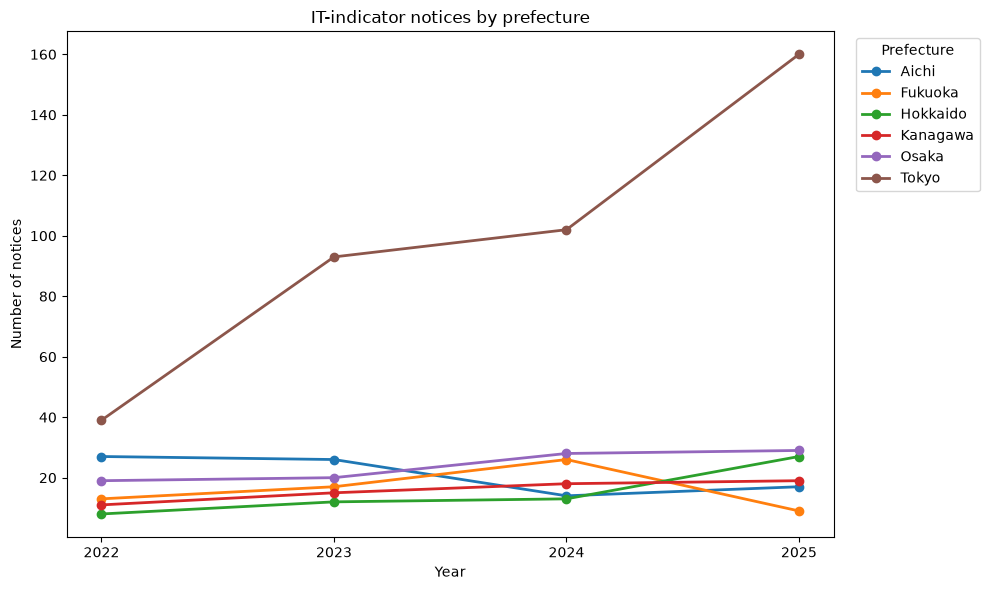

In [115]:
prefecture_count_matrix = (
       prefecture_annual.pivot(
           index="cft_issue_year",
           columns="prefecture_label",
           values="it_notices",
       )
   )

fig, ax = plt.subplots(figsize=(10, 6))

for prefecture in prefecture_count_matrix.columns:
    ax.plot(
           prefecture_count_matrix.index,
           prefecture_count_matrix[prefecture],
           marker="o",
           linewidth=2,
           label=prefecture,
       )

    ax.set_title("IT-indicator notices by prefecture")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of notices")
    ax.set_xticks(prefecture_count_matrix.index)
    ax.legend(
       title="Prefecture",
       bbox_to_anchor=(1.02, 1),
       loc="upper left",
   )

fig.tight_layout()
plt.show()

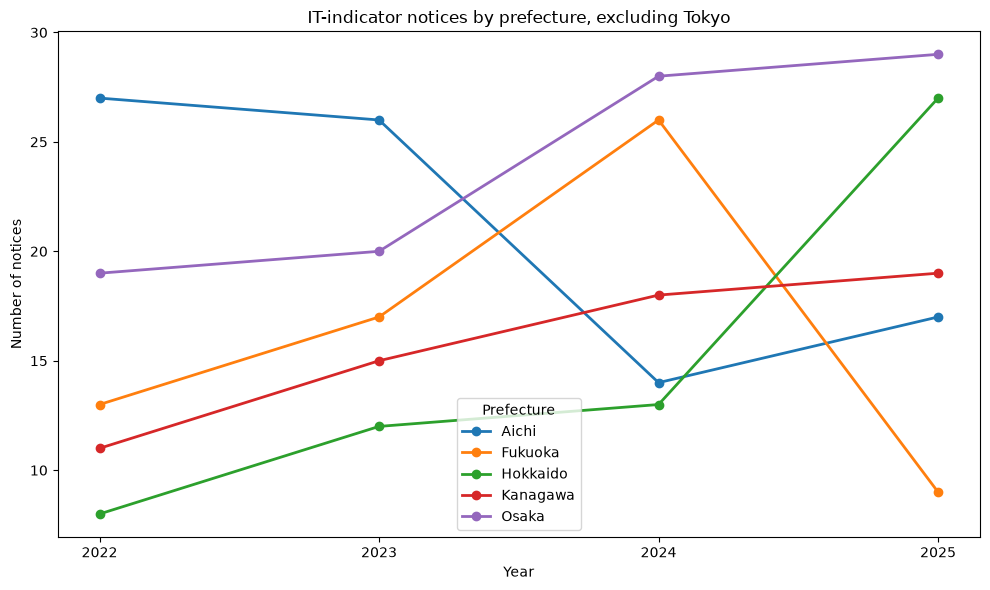

In [122]:
fig, ax = plt.subplots(figsize=(10, 6))

for prefecture in prefecture_count_matrix.columns:
       if prefecture == "Tokyo":
           continue

       ax.plot(
           prefecture_count_matrix.index,
           prefecture_count_matrix[prefecture],
           marker="o",
           linewidth=2,
           label=prefecture,
       )

ax.set_title(
       "IT-indicator notices by prefecture, excluding Tokyo"
   )
ax.set_xlabel("Year")
ax.set_ylabel("Number of notices")
ax.set_xticks(prefecture_count_matrix.index)
ax.legend(title="Prefecture")

fig.tight_layout()
plt.show()

In [132]:
# 3. Which organizations published the most IT-indicator notices in each prefecture and year, 
# and which ITsubgroups were most prominent in their notices?


it_notices = notices.loc[
       notices["it_related"]
   ].copy()

assert len(it_notices) == 762
assert it_notices["organization_name"].notna().all()

organization_annual = (
       it_notices.groupby(
           [
               "prefecture_name",
               "cft_issue_year",
               "organization_name",
           ],
           as_index=False,
       )
       .agg(
           it_notices=("key", "nunique"),
           core_it_notices=("core_it_delivery", "sum"),
           adjacent_only_notices=(
               "digital_or_ai_adjacent",
               "sum",
           ),
       )
   )

assert (
       organization_annual["it_notices"]
       == (
           organization_annual["core_it_notices"]
           + organization_annual["adjacent_only_notices"]
       )
   ).all()


organization_annual[
       "prefecture_year_it_notices"
   ] = (
       organization_annual.groupby(
           ["prefecture_name", "cft_issue_year"]
       )["it_notices"]
       .transform("sum")
   )


organization_annual[
       "organization_share_percent"
   ] = (
       organization_annual["it_notices"]
       / organization_annual[
           "prefecture_year_it_notices"
       ]
       * 100
   )

organization_annual["rank"] = (
       organization_annual.groupby(
           ["prefecture_name", "cft_issue_year"]
       )["it_notices"]
       .rank(
           method="min",
           ascending=False,
       )
       .astype(int)
   )


organization_annual["prefecture_label"] = (
       organization_annual["prefecture_name"].map(
           prefecture_labels
       )
   )

top_organizations = (
       organization_annual.loc[
           organization_annual["rank"] <= 5
       ]
       .sort_values(
           [
               "cft_issue_year",
               "prefecture_name",
               "rank",
               "organization_name",
           ]
       )
   )

top_organizations[
       [
           "cft_issue_year",
           "prefecture_label",
           "rank",
           "organization_name",
           "it_notices",
           "organization_share_percent",
           "core_it_notices",
           "adjacent_only_notices",
       ]
   ].round(2)

,cft_issue_year,prefecture_label,rank,organization_name,it_notices,organization_share_percent,core_it_notices,adjacent_only_notices
1,2022,Hokkaido,1,国土交通省北海道開発局留萌開発建設部,6,75.00,6,0
0,2022,Hokkaido,2,北海道,1,12.50,1,0
2,2022,Hokkaido,2,独立行政法人国立病院機構帯広病院,1,12.50,1,0
23,2022,Osaka,1,大阪府大阪市,7,36.84,7,0
24,2022,Osaka,2,大阪府箕面市,6,31.58,6,0
...,...,...,...,...,...,...,...,...
224,2025,Fukuoka,2,福岡県,2,22.22,2,0
220,2025,Fukuoka,3,国土交通省九州地方整備局,1,11.11,1,0
222,2025,Fukuoka,3,独立行政法人国立病院機構九州医療センター,1,11.11,1,0
223,2025,Fukuoka,3,独立行政法人国立病院機構大牟田病院,1,11.11,1,0


In [134]:
top_organizations.loc[
       top_organizations["cft_issue_year"].eq(2025),
       [
           "prefecture_label",
           "rank",
           "organization_name",
           "it_notices",
           "organization_share_percent",
       ],
   ].round(2)

,prefecture_label,rank,organization_name,it_notices,organization_share_percent
14,Hokkaido,1,北海道,13,48.15
22,Hokkaido,2,防衛省陸上自衛隊北部方面会計隊本部,3,11.11
15,Hokkaido,3,北海道伊達市,2,7.41
16,Hokkaido,3,北海道夕張市,2,7.41
18,Hokkaido,3,厚生労働省北海道労働局,2,7.41
19,Hokkaido,3,国家公安委員会（警察庁）北海道警察本部会計課,2,7.41
39,Osaka,1,大阪府大阪市,9,31.03
41,Osaka,1,大阪府箕面市,9,31.03
42,Osaka,3,大阪府門真市,3,10.34
43,Osaka,4,独立行政法人国立病院機構大阪刀根山医療センター,2,6.90


In [136]:
organization_subgroups = (
       it_notices.groupby(
           [
               "prefecture_name",
               "cft_issue_year",
               "organization_name",
           ],
           as_index=False,
       )[subgroup_columns]
       .sum()
   )

In [138]:
organization_annual = organization_annual.merge(
       organization_subgroups,
       on=[
           "prefecture_name",
           "cft_issue_year",
           "organization_name",
       ],
       validate="one_to_one",
   )

In [140]:
def find_leading_subgroups(
       row: pd.Series,
   ) -> str:
       counts = row[subgroup_columns]

       maximum = counts.max()

       if maximum == 0:
           return ""

       leaders = counts.index[
           counts.eq(maximum)
       ]

       return " | ".join(
           subgroup_labels[subgroup]
           for subgroup in leaders
       )

In [146]:
organization_annual.columns.tolist()

['prefecture_name',
 'cft_issue_year',
 'organization_name',
 'it_notices',
 'core_it_notices',
 'adjacent_only_notices',
 'prefecture_year_it_notices',
 'organization_share_percent',
 'rank',
 'prefecture_label',
 'system_development_x',
 'system_services_x',
 'software_applications_x',
 'operations_maintenance_x',
 'cloud_x',
 'cybersecurity_x',
 'network_infrastructure_x',
 'end_user_computing_x',
 'data_digital_x',
 'artificial_intelligence_x',
 'it_consulting_planning_x',
 'system_development_y',
 'system_services_y',
 'software_applications_y',
 'operations_maintenance_y',
 'cloud_y',
 'cybersecurity_y',
 'network_infrastructure_y',
 'end_user_computing_y',
 'data_digital_y',
 'artificial_intelligence_y',
 'it_consulting_planning_y']

In [148]:
organization_annual = (
       it_notices.groupby(
           [
               "prefecture_name",
               "cft_issue_year",
               "organization_name",
           ],
           as_index=False,
       )
       .agg(
           it_notices=("key", "nunique"),
           core_it_notices=("core_it_delivery", "sum"),
           adjacent_only_notices=(
               "digital_or_ai_adjacent",
               "sum",
           ),
           **{
               subgroup: (subgroup, "sum")
               for subgroup in subgroup_columns
           },
       )
   )

In [150]:
organization_annual[
       "prefecture_year_it_notices"
   ] = (
       organization_annual.groupby(
           ["prefecture_name", "cft_issue_year"]
       )["it_notices"]
       .transform("sum")
   )

organization_annual[
       "organization_share_percent"
   ] = (
       organization_annual["it_notices"]
       / organization_annual[
           "prefecture_year_it_notices"
       ]
       * 100
   )

organization_annual["rank"] = (
       organization_annual.groupby(
           ["prefecture_name", "cft_issue_year"]
       )["it_notices"]
       .rank(
           method="min",
           ascending=False,
       )
       .astype(int)
   )

organization_annual["prefecture_label"] = (
       organization_annual["prefecture_name"].map(
           prefecture_labels
       )
   )

In [152]:
[
       column
       for column in organization_annual.columns
       if column.endswith(("_x", "_y"))
   ]

[]

In [155]:
assert set(subgroup_columns).issubset(
       organization_annual.columns
   )

In [157]:
def find_leading_subgroups(
       row: pd.Series,
   ) -> str:
       counts = row.loc[subgroup_columns].astype(int)

       maximum = counts.max()

       if maximum == 0:
           return ""

       leading_columns = counts.index[
           counts.eq(maximum)
       ]

       return " | ".join(
           subgroup_labels[subgroup]
           for subgroup in leading_columns
       )

In [159]:
organization_annual["leading_subgroups"] = (
       organization_annual.apply(
           find_leading_subgroups,
           axis=1,
       )
   )

organization_annual["leading_subgroup_count"] = (
       organization_annual[subgroup_columns]
       .max(axis=1)
       .astype(int)
   )

In [161]:
assert (
       organization_annual["leading_subgroup_count"]
       <= organization_annual["it_notices"]
   ).all()

In [163]:
organization_annual[
       [
           "prefecture_label",
           "cft_issue_year",
           "organization_name",
           "it_notices",
           "leading_subgroups",
           "leading_subgroup_count",
       ]
   ].head(20)

,prefecture_label,cft_issue_year,organization_name,it_notices,leading_subgroups,leading_subgroup_count
0,Hokkaido,2022,北海道,1,System development,1
1,Hokkaido,2022,国土交通省北海道開発局留萌開発建設部,6,Operations and maintenance,4
2,Hokkaido,2022,独立行政法人国立病院機構帯広病院,1,Operations and maintenance,1
3,Hokkaido,2023,北海道,7,System development,5
4,Hokkaido,2023,北海道深川市,1,System development,1
5,Hokkaido,2023,厚生労働省北海道労働局,1,System development,1
6,Hokkaido,2023,国土交通省北海道開発局留萌開発建設部,2,Operations and maintenance,2
7,Hokkaido,2023,独立行政法人国立病院機構北海道がんセンター,1,Operations and maintenance,1
8,Hokkaido,2024,北海道,3,Operations and maintenance,2
9,Hokkaido,2024,国家公安委員会（警察庁）北海道警察本部会計課,4,System development | Operations and maintenance,2


In [165]:
top_organizations = (
       organization_annual.loc[
           organization_annual["rank"] <= 5
       ]
       .sort_values(
           [
               "cft_issue_year",
               "prefecture_name",
               "rank",
               "organization_name",
           ]
       )
   )

In [167]:
top_organizations[
       [
           "cft_issue_year",
           "prefecture_label",
           "rank",
           "organization_name",
           "it_notices",
           "organization_share_percent",
           "leading_subgroups",
           "leading_subgroup_count",
       ]
   ].round(2)

,cft_issue_year,prefecture_label,rank,organization_name,it_notices,organization_share_percent,leading_subgroups,leading_subgroup_count
1,2022,Hokkaido,1,国土交通省北海道開発局留萌開発建設部,6,75.00,Operations and maintenance,4
0,2022,Hokkaido,2,北海道,1,12.50,System development,1
2,2022,Hokkaido,2,独立行政法人国立病院機構帯広病院,1,12.50,Operations and maintenance,1
23,2022,Osaka,1,大阪府大阪市,7,36.84,System development | Operations and maintenance | Cloud | Data and digital | IT consulting and planning,2
24,2022,Osaka,2,大阪府箕面市,6,31.58,System development | Operations and maintenance | Network infrastructure,2
...,...,...,...,...,...,...,...,...
224,2025,Fukuoka,2,福岡県,2,22.22,System development,2
220,2025,Fukuoka,3,国土交通省九州地方整備局,1,11.11,Operations and maintenance,1
222,2025,Fukuoka,3,独立行政法人国立病院機構九州医療センター,1,11.11,Operations and maintenance,1
223,2025,Fukuoka,3,独立行政法人国立病院機構大牟田病院,1,11.11,Operations and maintenance,1


In [169]:
top_organizations.loc[
       top_organizations["cft_issue_year"].eq(2025),
       [
           "prefecture_label",
           "rank",
           "organization_name",
           "it_notices",
           "organization_share_percent",
           "leading_subgroups",
           "leading_subgroup_count",
       ],
   ].round(2)

,prefecture_label,rank,organization_name,it_notices,organization_share_percent,leading_subgroups,leading_subgroup_count
14,Hokkaido,1,北海道,13,48.15,System development,8
22,Hokkaido,2,防衛省陸上自衛隊北部方面会計隊本部,3,11.11,Software and applications,3
15,Hokkaido,3,北海道伊達市,2,7.41,Cloud | Cybersecurity,1
16,Hokkaido,3,北海道夕張市,2,7.41,System development,2
18,Hokkaido,3,厚生労働省北海道労働局,2,7.41,System development,2
19,Hokkaido,3,国家公安委員会（警察庁）北海道警察本部会計課,2,7.41,Operations and maintenance,2
39,Osaka,1,大阪府大阪市,9,31.03,System development | System services | Data and digital,2
41,Osaka,1,大阪府箕面市,9,31.03,System development,7
42,Osaka,3,大阪府門真市,3,10.34,Operations and maintenance,3
43,Osaka,4,独立行政法人国立病院機構大阪刀根山医療センター,2,6.90,System development | Operations and maintenance | IT consulting and planning,1


In [171]:
top_five_2025 = (
       organization_annual.loc[
           organization_annual[
               "cft_issue_year"
           ].eq(2025)
       ]
       .sort_values(
           [
               "prefecture_name",
               "it_notices",
               "organization_name",
           ],
           ascending=[True, False, True],
       )
       .groupby(
           "prefecture_name",
           group_keys=False,
       )
       .head(5)
   )

In [178]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

mpl.rcParams["font.family"] = "Hiragino Sans"
mpl.rcParams["axes.unicode_minus"] = False

print(
       font_manager.findfont(
           "Hiragino Sans"
       )
   )

/System/Library/Fonts/ヒラギノ角ゴシック W4.ttc


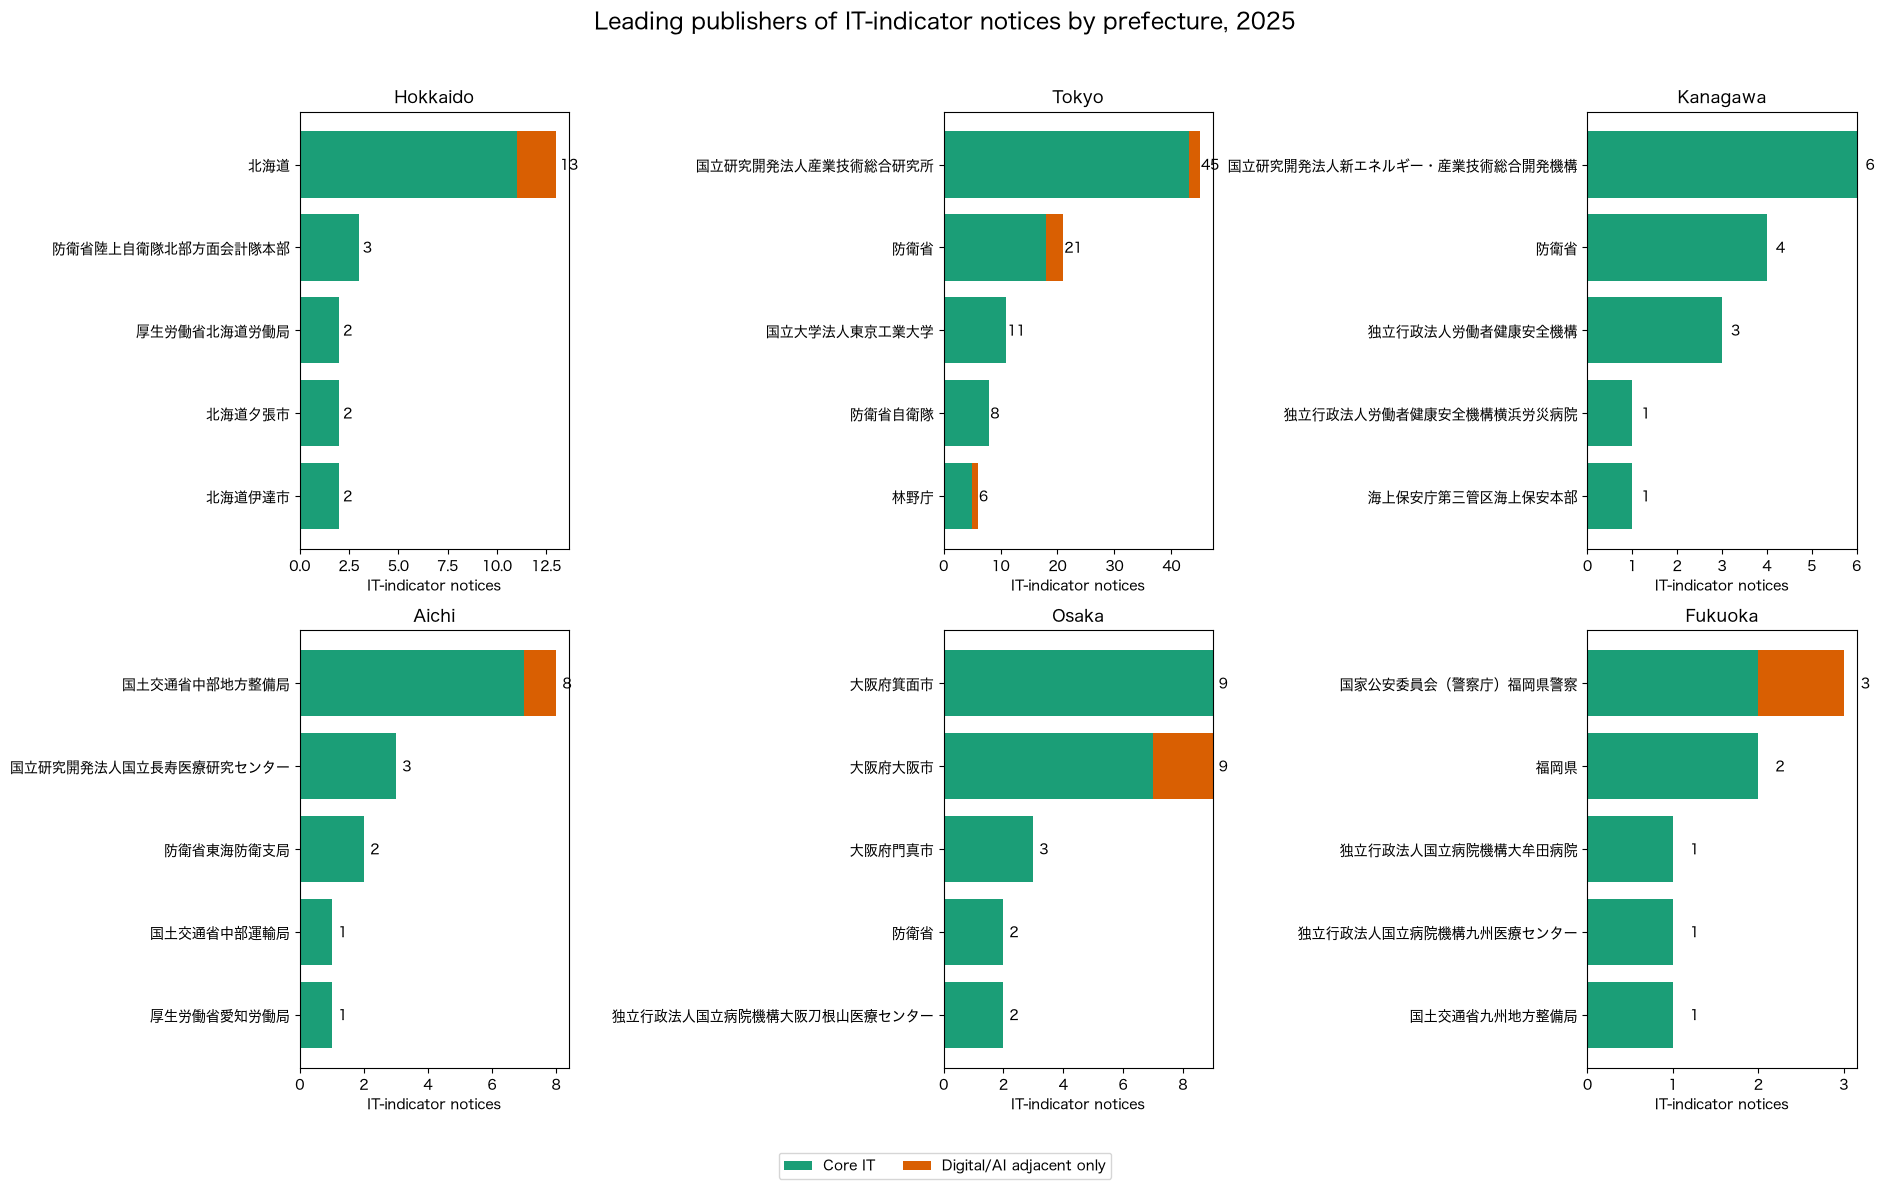

In [180]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(19, 12),
)

axes = axes.flatten()

prefecture_order = [
    "北海道",
    "東京都",
    "神奈川県",
    "愛知県",
    "大阪府",
    "福岡県",
]

for ax, prefecture in zip(
    axes,
    prefecture_order,
    strict=True,
):
    subset = (
        top_five_2025.loc[
            top_five_2025["prefecture_name"].eq(prefecture)
        ]
        .sort_values("it_notices")
    )

    # Core IT portion
    ax.barh(
        subset["organization_name"],
        subset["core_it_notices"],
        color="#1b9e77",
        label="Core IT",
    )

    # Adjacent-only portion
    ax.barh(
        subset["organization_name"],
        subset["adjacent_only_notices"],
        left=subset["core_it_notices"],
        color="#d95f02",
        label="Digital/AI adjacent only",
    )

    # Add total count labels
    for position, total in enumerate(
        subset["it_notices"]
    ):
        ax.text(
            total + 0.2,
            position,
            str(total),
            va="center",
        )

    ax.set_title(
        prefecture_labels[prefecture]
    )
    ax.set_xlabel("IT-indicator notices")

fig.suptitle(
    "Leading publishers of IT-indicator notices by prefecture, 2025",
    fontsize=16,
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, 0),
)

fig.tight_layout(rect=[0, 0.05, 1, 0.96])

plt.show()

In [182]:
top_three_2025 = (
       organization_annual.loc[
           organization_annual[
               "cft_issue_year"
           ].eq(2025)
           & organization_annual["rank"].le(3)
       ]
       .sort_values(
           [
               "prefecture_name",
               "rank",
               "organization_name",
           ]
       )
   )

In [184]:
top_three_2025_table = top_three_2025[
       [
           "prefecture_label",
           "rank",
           "organization_name",
           "it_notices",
           "organization_share_percent",
           "core_it_notices",
           "adjacent_only_notices",
           "leading_subgroups",
           "leading_subgroup_count",
       ]
   ].copy()

top_three_2025_table[
       "organization_share_percent"
   ] = top_three_2025_table[
       "organization_share_percent"
   ].round(1)

top_three_2025_table

,prefecture_label,rank,organization_name,it_notices,organization_share_percent,core_it_notices,adjacent_only_notices,leading_subgroups,leading_subgroup_count
14,Hokkaido,1,北海道,13,48.10,11,2,System development,8
22,Hokkaido,2,防衛省陸上自衛隊北部方面会計隊本部,3,11.10,3,0,Software and applications,3
15,Hokkaido,3,北海道伊達市,2,7.40,2,0,Cloud | Cybersecurity,1
16,Hokkaido,3,北海道夕張市,2,7.40,2,0,System development,2
18,Hokkaido,3,厚生労働省北海道労働局,2,7.40,2,0,System development,2
19,Hokkaido,3,国家公安委員会（警察庁）北海道警察本部会計課,2,7.40,2,0,Operations and maintenance,2
39,Osaka,1,大阪府大阪市,9,31.00,7,2,System development | System services | Data and digital,2
41,Osaka,1,大阪府箕面市,9,31.00,9,0,System development,7
42,Osaka,3,大阪府門真市,3,10.30,3,0,Operations and maintenance,3
66,Aichi,1,国土交通省中部地方整備局,8,47.10,7,1,System development,5


In [186]:
top_three_2025_table = (
       top_three_2025_table.rename(
           columns={
               "prefecture_label": "Prefecture",
               "rank": "Rank",
               "organization_name": "Organization",
               "it_notices": "IT notices",
               "organization_share_percent": (
                   "Share of prefecture IT notices (%)"
               ),
               "core_it_notices": "Core IT",
               "adjacent_only_notices": "Adjacent only",
               "leading_subgroups": "Leading subgroup(s)",
               "leading_subgroup_count": (
                   "Leading subgroup count"
               ),
           }
       )
   )

In [188]:
report_table_path = Path(
       "analysis_outputs/report_tables/"
       "top_organizations_by_prefecture_year.csv"
   )

report_table_path.parent.mkdir(
       parents=True,
       exist_ok=True,
   )

top_organizations.to_csv(
       report_table_path,
       index=False,
   )

In [190]:
# Which organizations experienced the largest annual increases in IT-indicator notices, and which detailed
# subgroups contributed most to those increases?


organization_year_observed = (
       it_notices.groupby(
           [
               "prefecture_name",
               "organization_name",
               "cft_issue_year",
           ],
           as_index=False,
       )
       .agg(
           it_notices=("key", "nunique"),
           **{
               subgroup: (subgroup, "sum")
               for subgroup in subgroup_columns
           },
       )
   )



In [192]:
organization_identifiers = (
       organization_year_observed[
           [
               "prefecture_name",
               "organization_name",
           ]
       ]
       .drop_duplicates()
   )

report_years = pd.DataFrame({
       "cft_issue_year": [
           2022,
           2023,
           2024,
           2025,
       ]
   })

organization_panel = (
       organization_identifiers.merge(
           report_years,
           how="cross",
       )
       .merge(
           organization_year_observed,
           on=[
               "prefecture_name",
               "organization_name",
               "cft_issue_year",
           ],
           how="left",
           validate="one_to_one",
       )
   )

In [194]:
count_columns = [
       "it_notices",
       *subgroup_columns,
   ]

organization_panel[count_columns] = (
       organization_panel[count_columns]
       .fillna(0)
       .astype(int)
   )

In [196]:
organization_panel["prefecture_label"] = (
       organization_panel["prefecture_name"].map(
           prefecture_labels
       )
   )

In [198]:
organization_panel = (
       organization_panel.sort_values(
           [
               "prefecture_name",
               "organization_name",
               "cft_issue_year",
           ]
       )
       .reset_index(drop=True)
   )

In [200]:
organization_groups = (
       organization_panel.groupby(
           [
               "prefecture_name",
               "organization_name",
           ]
       )
   )

organization_panel["previous_it_notices"] = (
       organization_groups["it_notices"].shift(1)
   )

In [202]:
organization_panel[
       "it_absolute_annual_change"
   ] = (
       organization_panel["it_notices"]
       - organization_panel["previous_it_notices"]
   )

In [204]:
organization_panel["it_yoy_percent"] = (
       (
           organization_panel["it_notices"]
           / organization_panel["previous_it_notices"]
           - 1
       )
       * 100
   )

organization_panel.loc[
       organization_panel[
           "previous_it_notices"
       ].le(0),
       "it_yoy_percent",
   ] = pd.NA

In [206]:
organization_panel["growth_status"] = "continuing"

organization_panel.loc[
       organization_panel[
           "previous_it_notices"
       ].eq(0)
       & organization_panel["it_notices"].gt(0),
       "growth_status",
   ] = "new_or_returning"

organization_panel.loc[
       organization_panel["it_notices"].eq(0),
       "growth_status",
   ] = "no_notices"

In [208]:
subgroup_change_columns = []

for subgroup in subgroup_columns:
       change_column = f"{subgroup}_annual_change"

       organization_panel[change_column] = (
           organization_groups[subgroup].diff()
       )

       subgroup_change_columns.append(
           change_column
       )

In [210]:
def find_growth_subgroups(
       row: pd.Series,
   ) -> str:
       changes = pd.Series({
           subgroup: row[
               f"{subgroup}_annual_change"
           ]
           for subgroup in subgroup_columns
       })

       maximum = changes.max()

       if pd.isna(maximum) or maximum <= 0:
           return ""

       leaders = changes.index[
           changes.eq(maximum)
       ]

       return " | ".join(
           subgroup_labels[subgroup]
           for subgroup in leaders
       )

In [212]:
organization_panel[
       "leading_growth_subgroups"
   ] = organization_panel.apply(
       find_growth_subgroups,
       axis=1,
   )

organization_panel[
       "leading_subgroup_increase"
   ] = organization_panel[
       subgroup_change_columns
   ].max(axis=1)

In [214]:
positive_organization_growth = (
       organization_panel.loc[
           organization_panel[
               "cft_issue_year"
           ].gt(2022)
           & organization_panel[
               "it_absolute_annual_change"
           ].gt(0)
       ]
       .copy()
   )

In [216]:
positive_organization_growth[
       "growth_rank_within_prefecture"
   ] = (
       positive_organization_growth.groupby(
           [
               "prefecture_name",
               "cft_issue_year",
           ]
       )["it_absolute_annual_change"]
       .rank(
           method="min",
           ascending=False,
       )
       .astype(int)
   )

In [218]:
top_growth_by_prefecture_year = (
       positive_organization_growth.loc[
           positive_organization_growth[
               "growth_rank_within_prefecture"
           ].le(3)
       ]
       .sort_values(
           [
               "cft_issue_year",
               "prefecture_name",
               "growth_rank_within_prefecture",
               "organization_name",
           ]
       )
   )

In [220]:
top_growth_by_prefecture_year[
       [
           "cft_issue_year",
           "prefecture_label",
           "growth_rank_within_prefecture",
           "organization_name",
           "previous_it_notices",
           "it_notices",
           "it_absolute_annual_change",
           "it_yoy_percent",
           "growth_status",
           "leading_growth_subgroups",
           "leading_subgroup_increase",
       ]
   ].round(1)

,cft_issue_year,prefecture_label,growth_rank_within_prefecture,organization_name,previous_it_notices,it_notices,it_absolute_annual_change,it_yoy_percent,growth_status,leading_growth_subgroups,leading_subgroup_increase
1,2023,Hokkaido,1,北海道,1.00,7,6.00,600.00,continuing,System development,4.00
17,2023,Hokkaido,2,北海道深川市,0.00,1,1.00,NaN,new_or_returning,System development,1.00
21,2023,Hokkaido,2,厚生労働省北海道労働局,0.00,1,1.00,NaN,new_or_returning,System development,1.00
33,2023,Hokkaido,2,独立行政法人国立病院機構北海道がんセンター,0.00,1,1.00,NaN,new_or_returning,Operations and maintenance,1.00
57,2023,Osaka,1,大阪府大阪市,7.00,11,4.00,57.10,continuing,Software and applications,4.00
...,...,...,...,...,...,...,...,...,...,...,...
383,2025,Kanagawa,3,独立行政法人国立病院機構箱根病院,0.00,1,1.00,NaN,new_or_returning,Operations and maintenance,1.00
391,2025,Kanagawa,3,神奈川県逗子市,0.00,1,1.00,NaN,new_or_returning,Network infrastructure,1.00
419,2025,Fukuoka,1,国家公安委員会（警察庁）福岡県警察,2.00,3,1.00,50.00,continuing,System development,1.00
431,2025,Fukuoka,1,独立行政法人国立病院機構九州医療センター,0.00,1,1.00,NaN,new_or_returning,Operations and maintenance,1.00


In [222]:
established_organization_growth = (
       positive_organization_growth.loc[
           positive_organization_growth[
               "previous_it_notices"
           ].ge(3)
       ]
       .sort_values(
           [
               "cft_issue_year",
               "it_yoy_percent",
           ],
           ascending=[True, False],
       )
   )

In [224]:
largest_annual_increases = (
       positive_organization_growth.sort_values(
           [
               "cft_issue_year",
               "it_absolute_annual_change",
           ],
           ascending=[True, False],
       )
       .groupby(
           "cft_issue_year",
           group_keys=False,
       )
       .head(10)
   )

In [226]:
largest_annual_increases[
       [
           "cft_issue_year",
           "prefecture_label",
           "organization_name",
           "previous_it_notices",
           "it_notices",
           "it_absolute_annual_change",
           "growth_status",
           "leading_growth_subgroups",
           "leading_subgroup_increase",
       ]
   ].round(1)

,cft_issue_year,prefecture_label,organization_name,previous_it_notices,it_notices,it_absolute_annual_change,growth_status,leading_growth_subgroups,leading_subgroup_increase
321,2023,Tokyo,防衛省自衛隊,10.00,40,30.00,continuing,Operations and maintenance,13.00
125,2023,Aichi,国立研究開発法人国立長寿医療研究センター,3.00,13,10.00,continuing,Operations and maintenance,6.00
173,2023,Tokyo,国立大学法人東京工業大学,0.00,8,8.00,new_or_returning,System development | Operations and maintenance | Network infrastructure,3.00
217,2023,Tokyo,水産庁,3.00,10,7.00,continuing,System development,7.00
445,2023,Fukuoka,福岡県,0.00,7,7.00,new_or_returning,System development,3.00
1,2023,Hokkaido,北海道,1.00,7,6.00,continuing,System development,4.00
309,2023,Tokyo,防衛省,0.00,6,6.00,new_or_returning,Artificial intelligence,2.00
401,2023,Kanagawa,防衛省防衛大学校,0.00,6,6.00,new_or_returning,System development | Cloud | Network infrastructure,2.00
57,2023,Osaka,大阪府大阪市,7.00,11,4.00,continuing,Software and applications,4.00
277,2023,Tokyo,独立行政法人日本学生支援機構,0.00,4,4.00,new_or_returning,Operations and maintenance,4.00


In [229]:
chart_growth = (
       largest_annual_increases.copy()
   )

chart_growth["display_label"] = (
       chart_growth["organization_name"]
       + " ("
       + chart_growth["prefecture_label"]
       + ")"
   )

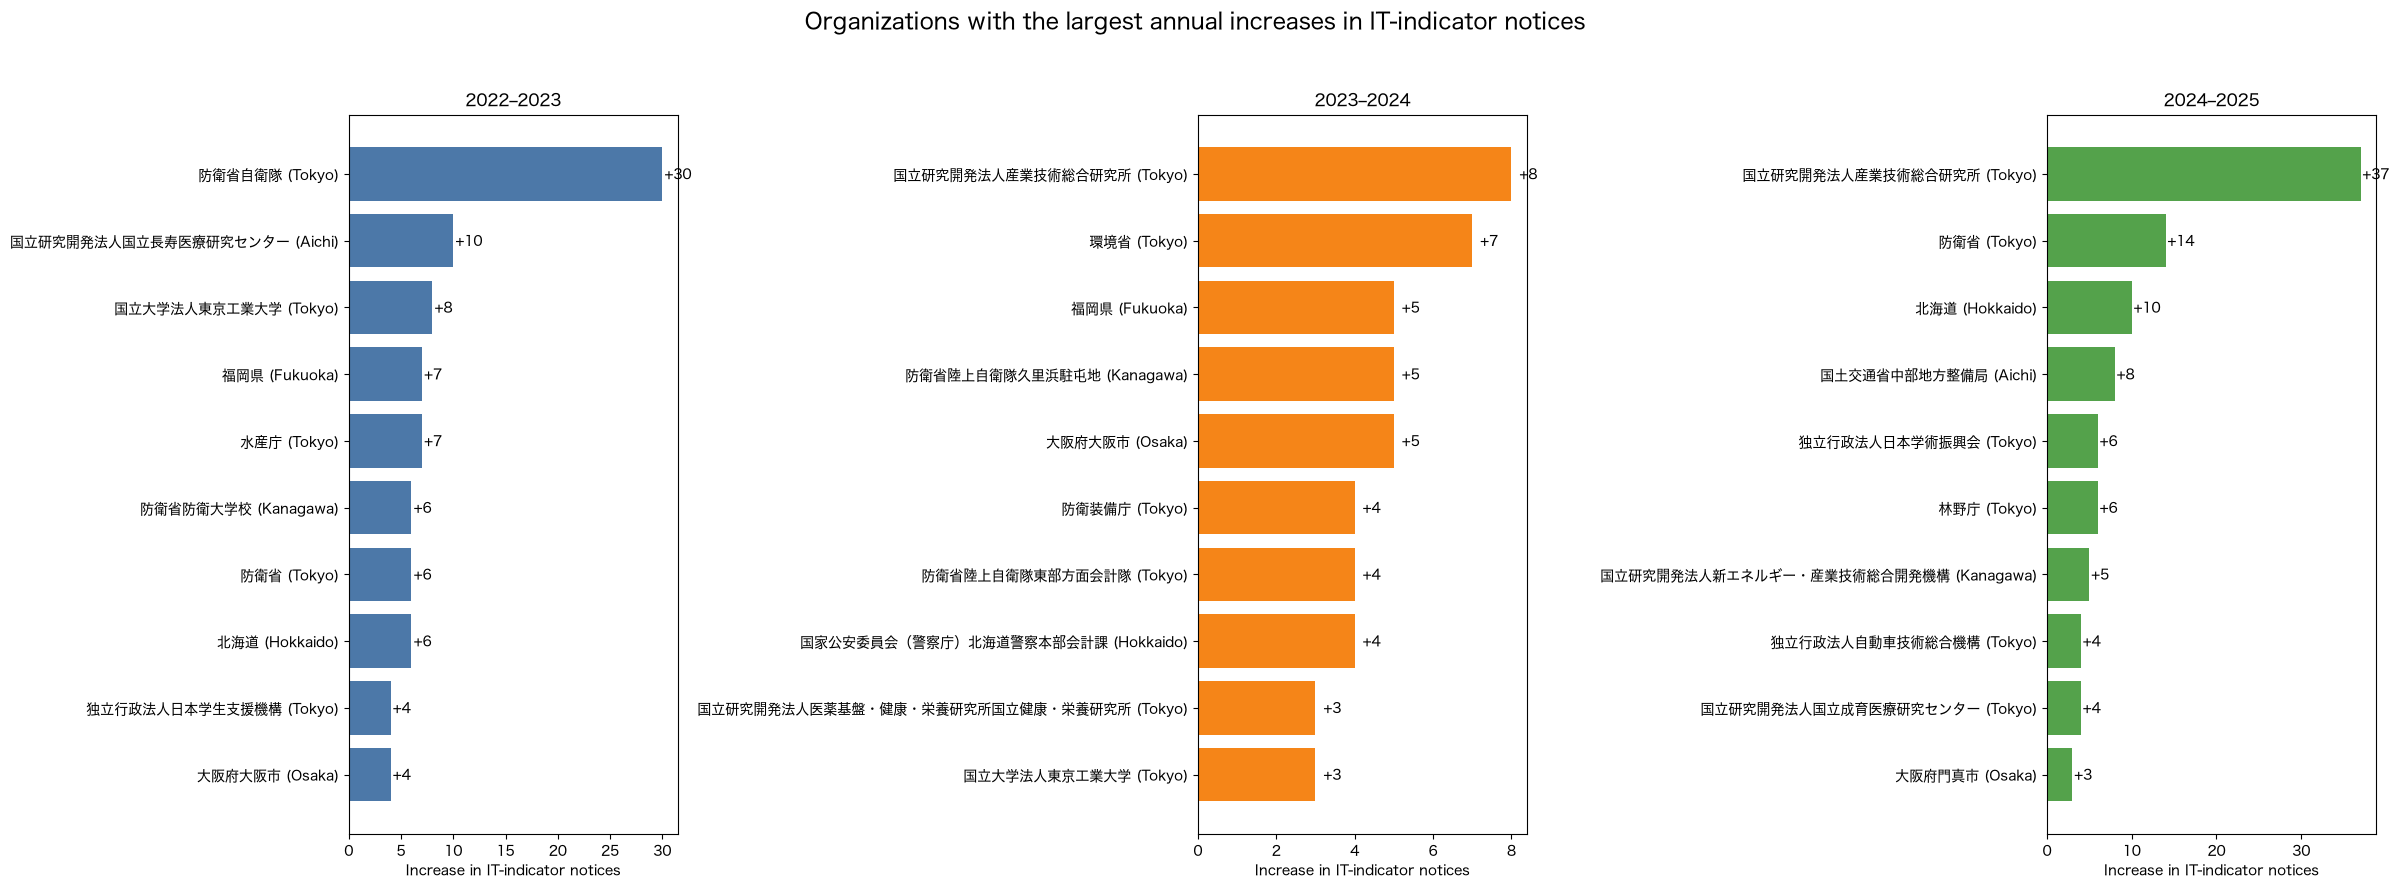

In [231]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 9),
)

comparison_years = [
    2023,
    2024,
    2025,
]

colors = {
    2023: "#4c78a8",
    2024: "#f58518",
    2025: "#54a24b",
}

for ax, year in zip(
    axes,
    comparison_years,
    strict=True,
):
    subset = (
        chart_growth.loc[
            chart_growth["cft_issue_year"].eq(year)
        ]
        .sort_values(
            "it_absolute_annual_change"
        )
    )

    ax.barh(
        subset["display_label"],
        subset["it_absolute_annual_change"],
        color=colors[year],
    )

    for position, value in enumerate(
        subset["it_absolute_annual_change"]
    ):
        ax.text(
            value + 0.2,
            position,
            f"+{int(value)}",
            va="center",
        )

    ax.set_title(
        f"{year - 1}–{year}"
    )
    ax.set_xlabel(
        "Increase in IT-indicator notices"
    )

fig.suptitle(
    "Organizations with the largest annual increases "
    "in IT-indicator notices",
    fontsize=16,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

In [233]:
organization_growth_report_table = (
       top_growth_by_prefecture_year[
           [
               "cft_issue_year",
               "prefecture_label",
               "growth_rank_within_prefecture",
               "organization_name",
               "previous_it_notices",
               "it_notices",
               "it_absolute_annual_change",
               "it_yoy_percent",
               "growth_status",
               "leading_growth_subgroups",
               "leading_subgroup_increase",
           ]
       ]
       .copy()
   )

In [235]:
organization_growth_report_table = (
       organization_growth_report_table.rename(
           columns={
               "cft_issue_year": "Year",
               "prefecture_label": "Prefecture",
               "growth_rank_within_prefecture": "Rank",
               "organization_name": "Organization",
               "previous_it_notices": "Previous year",
               "it_notices": "Current year",
               "it_absolute_annual_change": (
                   "Absolute increase"
               ),
               "it_yoy_percent": "YoY growth (%)",
               "growth_status": "Status",
               "leading_growth_subgroups": (
                   "Leading growth subgroup(s)"
               ),
               "leading_subgroup_increase": (
                   "Largest subgroup-tag increase"
               ),
           }
       )
   )

In [237]:
output_path = Path(
       "analysis_outputs/report_tables/"
       "organization_annual_growth.csv"
   )

output_path.parent.mkdir(
       parents=True,
       exist_ok=True,
   )

organization_panel.to_csv(
       output_path,
       index=False,
   )

In [33]:
# Which organizations have been issuing the most it related services in each rpefecture year over year


In [34]:
# which organizations have seen the biggest increases year over year and particuarly, in which subgroup

In [35]:
# Do we see any type of increases in competitive biddings, open, and public biddings 

In [36]:
# How do services differ in the type of bidding that is produced? Do we see large more public biddings for certain services?

In [ ]:
# Which subgroups have a larger number of public biddings, and private bidings, what is the split